# 04 - Algoritmos de Classificacao

Responsavel: Integrante 3

Objetivo: treinar e avaliar DOIS classificadores, comparar entre si e com o Bayes. Usar a MESMA divisao treino/teste do notebook 03 para comparacao justa.

In [28]:
import os

REPO_PATH = '/content/super-projeto-de-probabilidade-estatistica'

if not os.path.exists(REPO_PATH):
    !git clone https://github.com/Lucas-oss444/super-projeto-de-probabilidade-estatistica.git

os.chdir(REPO_PATH)
!git pull
print('CWD:', os.getcwd())

Already up to date.
CWD: /content/super-projeto-de-probabilidade-estatistica


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('data/dataset_tratado.csv')
print('Shape:', df.shape)
df.head()

Shape: (149999, 10)


,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,alvo,sem_vtat,hora,dia_semana,mes,periodo_dia
0,eBike,Palam Vihar,Jhilmil,8.3,0,1,12,5,3,tarde
1,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,0,0,18,4,11,noite
2,Auto,Khandsa,Malviya Nagar,13.4,1,0,8,4,8,manha
3,Premier Sedan,Central Secretariat,Inderlok,13.1,1,0,17,0,10,tarde
4,Bike,Ghitorni Village,Khan Market,5.3,1,0,22,0,9,noite


## 1. Preparacao (encoding + escala)

In [30]:
# Pickup/Drop Location excluídas: 176 valores únicos cada (alta cardinalidade)
FEATURES_CAT = ['Vehicle Type', 'periodo_dia']
FEATURES_NUM = ['Avg VTAT', 'sem_vtat', 'hora', 'dia_semana', 'mes']

X_cat = pd.get_dummies(df[FEATURES_CAT], drop_first=True)
X_num = df[FEATURES_NUM].copy()
X = pd.concat([X_cat, X_num], axis=1)
y = df['alvo']

# Mesma divisão do notebook 03 para comparação justa
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler apenas para Regressão Logística (árvore não precisa)
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[FEATURES_NUM] = scaler.fit_transform(X_train[FEATURES_NUM])
X_test_sc[FEATURES_NUM]  = scaler.transform(X_test[FEATURES_NUM])

print(f'Total de features: {X.shape[1]}')
print('Colunas:', X.columns.tolist())
print(f'\nTreino: {len(X_train):,}  |  Teste: {len(X_test):,}')

Total de features: 14
Colunas: ['Vehicle Type_Bike', 'Vehicle Type_Go Mini', 'Vehicle Type_Go Sedan', 'Vehicle Type_Premier Sedan', 'Vehicle Type_Uber XL', 'Vehicle Type_eBike', 'periodo_dia_manha', 'periodo_dia_noite', 'periodo_dia_tarde', 'Avg VTAT', 'sem_vtat', 'hora', 'dia_semana', 'mes']

Treino: 119,999  |  Teste: 30,000


## 2. Modelo A - Arvore de Decisao

In [31]:
arvore = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_leaf=50)
arvore.fit(X_train, y_train)
pred_a = arvore.predict(X_test)

acc_a  = accuracy_score(y_test, pred_a)
prec_a = precision_score(y_test, pred_a, zero_division=0)
rec_a  = recall_score(y_test, pred_a, zero_division=0)
f1_a   = f1_score(y_test, pred_a, zero_division=0)

print('=== ÁRVORE DE DECISÃO ===')
print(f'Profundidade: {arvore.get_depth()}  |  Folhas: {arvore.get_n_leaves()}')
print(f'Acurácia: {acc_a:.4f}  |  Precisão: {prec_a:.4f}  |  Recall: {rec_a:.4f}  |  F1: {f1_a:.4f}')
print()
print(classification_report(y_test, pred_a, target_names=['Não Concluída', 'Concluída']))

importancias = pd.Series(arvore.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Importância das features (top 8):')
print(importancias.head(8).round(4))

=== ÁRVORE DE DECISÃO ===
Profundidade: 8  |  Folhas: 52
Acurácia: 0.7102  |  Precisão: 0.6815  |  Recall: 1.0000  |  F1: 0.8106

               precision    recall  f1-score   support

Não Concluída       1.00      0.24      0.38     11400
    Concluída       0.68      1.00      0.81     18600

     accuracy                           0.71     30000
    macro avg       0.84      0.62      0.60     30000
 weighted avg       0.80      0.71      0.65     30000

Importância das features (top 8):
sem_vtat                 0.5517
Avg VTAT                 0.4451
mes                      0.0011
dia_semana               0.0008
hora                     0.0005
periodo_dia_tarde        0.0003
Vehicle Type_Go Sedan    0.0003
Vehicle Type_Bike        0.0001
dtype: float64


## 3. Modelo B - Regressao Logistica

In [32]:
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg.fit(X_train_sc, y_train)
pred_b = logreg.predict(X_test_sc)

acc_b  = accuracy_score(y_test, pred_b)
prec_b = precision_score(y_test, pred_b, zero_division=0)
rec_b  = recall_score(y_test, pred_b, zero_division=0)
f1_b   = f1_score(y_test, pred_b, zero_division=0)

print('=== REGRESSÃO LOGÍSTICA ===')
print(f'Iterações realizadas: {logreg.n_iter_[0]}')
print(f'Acurácia: {acc_b:.4f}  |  Precisão: {prec_b:.4f}  |  Recall: {rec_b:.4f}  |  F1: {f1_b:.4f}')
print()
print(classification_report(y_test, pred_b, target_names=['Não Concluída', 'Concluída']))

coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print('Coeficientes com maior impacto (top 8):')
print(coefs.head(8).round(4))

=== REGRESSÃO LOGÍSTICA ===
Iterações realizadas: 20
Acurácia: 0.6862  |  Precisão: 0.6640  |  Recall: 1.0000  |  F1: 0.7981

               precision    recall  f1-score   support

Não Concluída       1.00      0.17      0.30     11400
    Concluída       0.66      1.00      0.80     18600

     accuracy                           0.69     30000
    macro avg       0.83      0.59      0.55     30000
 weighted avg       0.79      0.69      0.61     30000

Coeficientes com maior impacto (top 8):
sem_vtat                     -2.6478
Avg VTAT                      0.0431
periodo_dia_tarde            -0.0256
Vehicle Type_Premier Sedan    0.0242
periodo_dia_noite            -0.0202
Vehicle Type_Uber XL          0.0169
Vehicle Type_Bike             0.0156
dia_semana                    0.0120
dtype: float64


## 4. Metricas e matriz de confusao

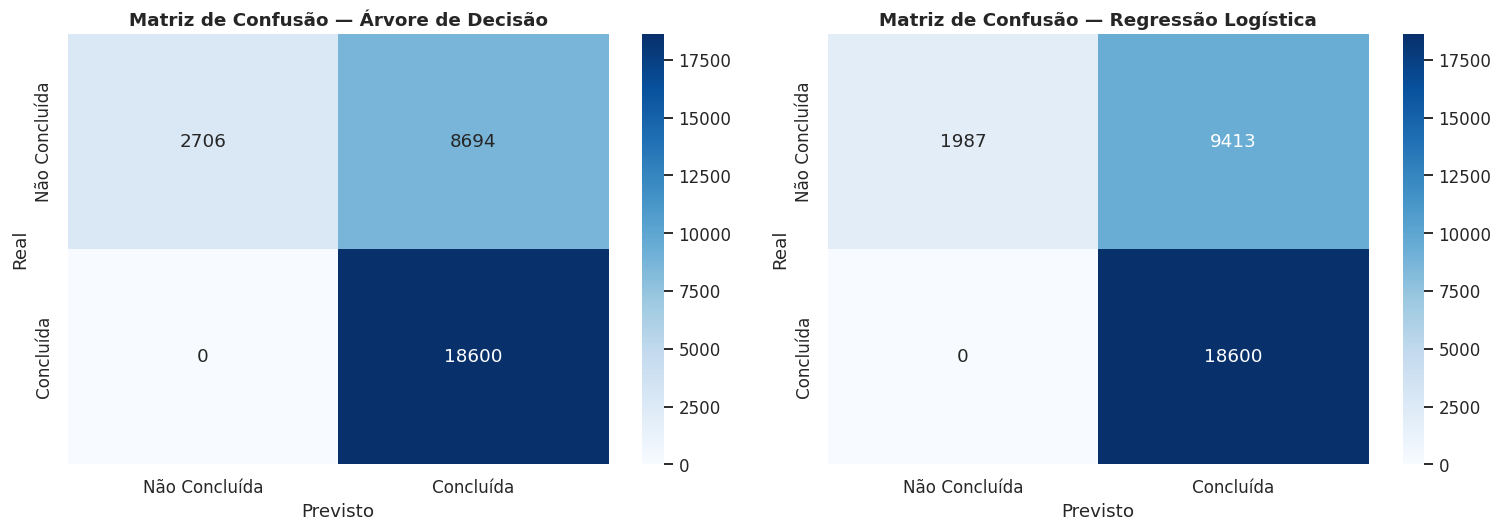

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred_cm, titulo in zip(
    axes,
    [pred_a, pred_b],
    ['Árvore de Decisão', 'Regressão Logística']
):
    cm = confusion_matrix(y_test, y_pred_cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Não Concluída', 'Concluída'],
                yticklabels=['Não Concluída', 'Concluída'], ax=ax)
    ax.set_title(f'Matriz de Confusão — {titulo}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Previsto')

plt.tight_layout()
plt.show()

## 5. Comparacao final

Tabela comparando Arvore x Regressao Logistica x Teorema de Bayes nas mesmas metricas, com discussao de qual se saiu melhor e por que.

=== COMPARAÇÃO FINAL DOS MODELOS ===

                     Acurácia  Precisão  Recall  F1-Score
Naive Bayes            0.6862    0.6640     1.0    0.7981
Árvore de Decisão      0.7102    0.6815     1.0    0.8106
Regressão Logística    0.6862    0.6640     1.0    0.7981


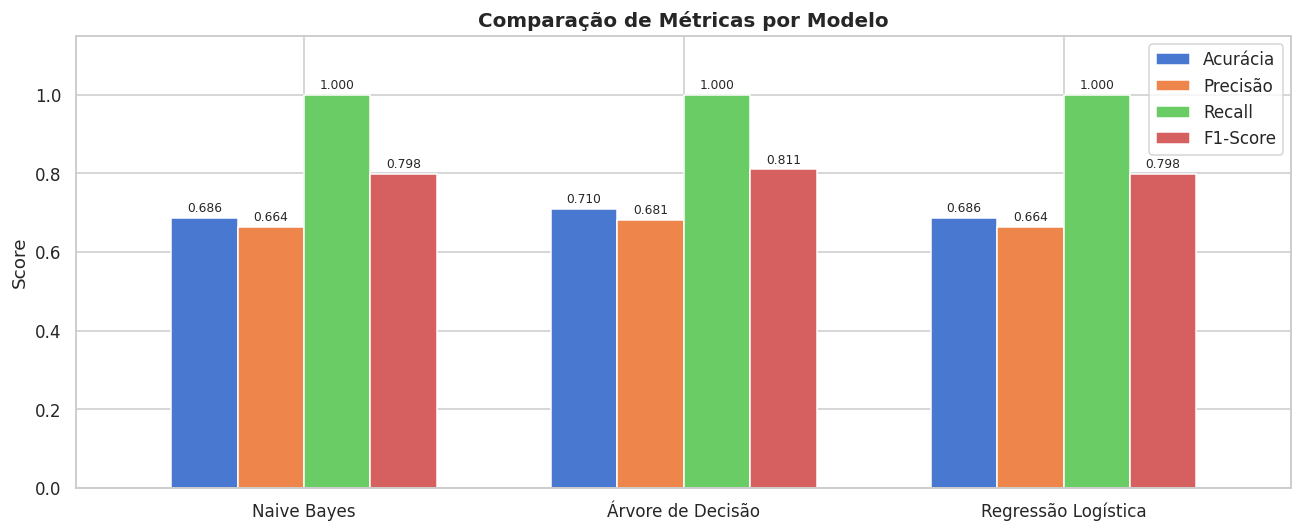


Melhor F1-Score: Árvore de Decisão (0.8106)

Naive Bayes:          modelo probabilístico, interpretável, 3 features discretas.
Árvore de Decisão:    captura relações não-lineares, não precisa de escala.
Regressão Logística:  modelo linear, usa todas as features numéricas e dummies.


In [34]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

# Recomputar Bayes com as mesmas features do notebook 03
PREDITORAS_BAYES = ['Vehicle Type', 'periodo_dia', 'sem_vtat']
X_b = df[PREDITORAS_BAYES]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y, test_size=0.2, random_state=42, stratify=y
)
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
nb = CategoricalNB(alpha=1.0)
nb.fit(enc.fit_transform(X_train_b.astype(str)), y_train_b)
pred_bayes = nb.predict(enc.transform(X_test_b.astype(str)))

resultados = pd.DataFrame({
    'Acurácia': [accuracy_score(y_test_b, pred_bayes), acc_a, acc_b],
    'Precisão': [precision_score(y_test_b, pred_bayes, zero_division=0), prec_a, prec_b],
    'Recall':   [recall_score(y_test_b, pred_bayes, zero_division=0), rec_a, rec_b],
    'F1-Score': [f1_score(y_test_b, pred_bayes, zero_division=0), f1_a, f1_b],
}, index=['Naive Bayes', 'Árvore de Decisão', 'Regressão Logística']).round(4)

print('=== COMPARAÇÃO FINAL DOS MODELOS ===\n')
print(resultados.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
resultados.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')
ax.set_title('Comparação de Métricas por Modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.set_xticklabels(resultados.index, rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

melhor = resultados['F1-Score'].idxmax()
print(f'\nMelhor F1-Score: {melhor} ({resultados.loc[melhor, "F1-Score"]:.4f})')
print('\nNaive Bayes:          modelo probabilístico, interpretável, 3 features discretas.')
print('Árvore de Decisão:    captura relações não-lineares, não precisa de escala.')
print('Regressão Logística:  modelo linear, usa todas as features numéricas e dummies.')